# AG-HYPOPT · Trial 16

> ▶ RUN = execute this cell, never modify it  ·  ✍️ WRITE = replace the [placeholder] with your text  ·  ✍️ SET = put your value where the [placeholder] is, then run the cell. Full rules: `instructions.md`


## 1. ✍️ WRITE - Read and summarize

Read `context.md` (physics/model knowledge). If there are previous trials, read them too
(all `trial_XX` notebooks numbered lower than this one) and `trials.json` (the registry).
The current best is the recorded trial with the lowest objective; it is the reference
for the cell-3 choice.

Fifteen trials are recorded. Best is trial_07 (sw 0.865, h_f 4.0, h_s 3.675, cap 0.107) at 0.0803. The rest cluster above it: trial_05 0.0822, trial_09 0.0839, trial_11 0.0859, trial_06 0.0861, trial_15 0.0865, trial_08 0.0876, trial_12 0.0882, trial_13 0.0888, trial_14 0.0904, trial_10 0.0922. All 0 diverged, gamma finite. The optimum is a narrow interior point: sw ~0.85, h_f ~3.9-4.0, h_s ~3.6-3.7, cap ~0.1; trials 08-15 densely sampled its surroundings without improving on trial_07. Phase 'trials'.


In [ ]:
# 2. ▶ RUN - Propose candidate trials (AGHyperopt)
TRIAL_ID = 'trial_16'   # auto-stamped by the generator; do not edit
import os

EXPERIMENT_DIR = os.getcwd()
SPACE_PATH = os.path.join(EXPERIMENT_DIR, 'space.json')
TRIALS_PATH = os.path.join(EXPERIMENT_DIR, 'trials.json')

MAX_TRIALS = 30    # campaign cap: stop generating new trials after this many (None = unlimited)

from ag_hypopt import AGHyperopt, trial_seed

opt = AGHyperopt(seed=trial_seed(TRIAL_ID))   # per-trial seed: fresh draws every trial
opt.fit(SPACE_PATH, TRIALS_PATH)
proposed_trials = opt.propose_trials(10)


phase = trials  (15/5 trials)
ID |     ei | params
 1 | 3.1948 | {"gamma_rel_cap": 0.2521902173953438, "h_f_scale": 1.555298314134983, "h_s_scale": 3.576407779572558, "sigma_weight": 0.6047138368243267}
 2 | 0.9865 | {"gamma_rel_cap": 0.40121048143295207, "h_f_scale": 2.858589680869728, "h_s_scale": 2.8435740849372495, "sigma_weight": 0.6004744723659212}
 3 | 3.6459 | {"gamma_rel_cap": 0.26293532390131014, "h_f_scale": 3.995816103394374, "h_s_scale": 3.9434946543210674, "sigma_weight": 0.8640418204843848}
 4 | 3.7573 | {"gamma_rel_cap": 0.19237075593276098, "h_f_scale": 3.9918087560011557, "h_s_scale": 3.514204109814147, "sigma_weight": 0.729884858046672}
 5 | 3.8898 | {"gamma_rel_cap": 0.20244989516447662, "h_f_scale": 3.9043717025275044, "h_s_scale": 3.854234359406956, "sigma_weight": 0.5801167365415937}
 6 | 3.9523 | {"gamma_rel_cap": 0.14034204296916925, "h_f_scale": 4.0, "h_s_scale": 3.607939150628629, "sigma_weight": 0.5119470434183231}
 7 | 3.9834 | {"gamma_rel_cap": 0.494601486

## 3. ✍️ WRITE - Analyze and choose

Using the summary from cell 1 (previous trials + registry) and the candidate table from
cell 2, choose the ONE proposal that makes the most sense for the next trial. No hypothesis
and no expectation are needed: base the choice on what the trials have shown and on the
candidates themselves.

trial_07 remains unbeaten and trials 08-15 densely bracket it. The batch's top-ei draw (id 7) has a very large gamma cap (0.495), off the known-good band; candidate 6 is the highest-ei draw that keeps the kernels near optimal with a cap (0.140) inside the good band.

Candidate 6 (ei 3.9523) holds h_f 4.0 and a flat h_s (3.608) with cap 0.140, and sets sigma_weight 0.512 - close to trial_06's 0.497, which produced the best mu (34.0%) of any trial. It is the clearest in-band draw in this batch and re-tests the moderate-low sigma weight that gave the strongest mu without the previous trial's poorer kernels.

I choose candidate 6.


In [ ]:
# 4. ✍️ SET - Chosen candidate (edit INDEX below, then run this cell)
INDEX = 6               # candidate 6: sigma_weight 0.512, h_f_scale 4.0, h_s_scale 3.608, gamma_rel_cap 0.140 (in-band, moderate-low sw)


chosen: {'gamma_rel_cap': 0.14034204296916925, 'h_f_scale': 4.0, 'h_s_scale': 3.607939150628629, 'sigma_weight': 0.5119470434183231}
Running  1nW Trans05 ... 

μ 9.39 -> 5.96 | γ 8.5 -> 5.51 | NLL 0.20


Running  1nW Trans20 ... 

μ 17.32 -> 26.26 | γ 8.5 -> 5.35 | NLL 0.55


Running  1nW Trans60 ... 

...

Running  3nW Trans60 ... 

μ 103.20 -> 64.16 | γ 14.1 -> 14.01 | NLL 0.64


Running 3nW Trans100 ... 

μ 175.71 -> 94.71 | γ 14.1 -> 13.72 | NLL 0.62



Total: 7.8 min


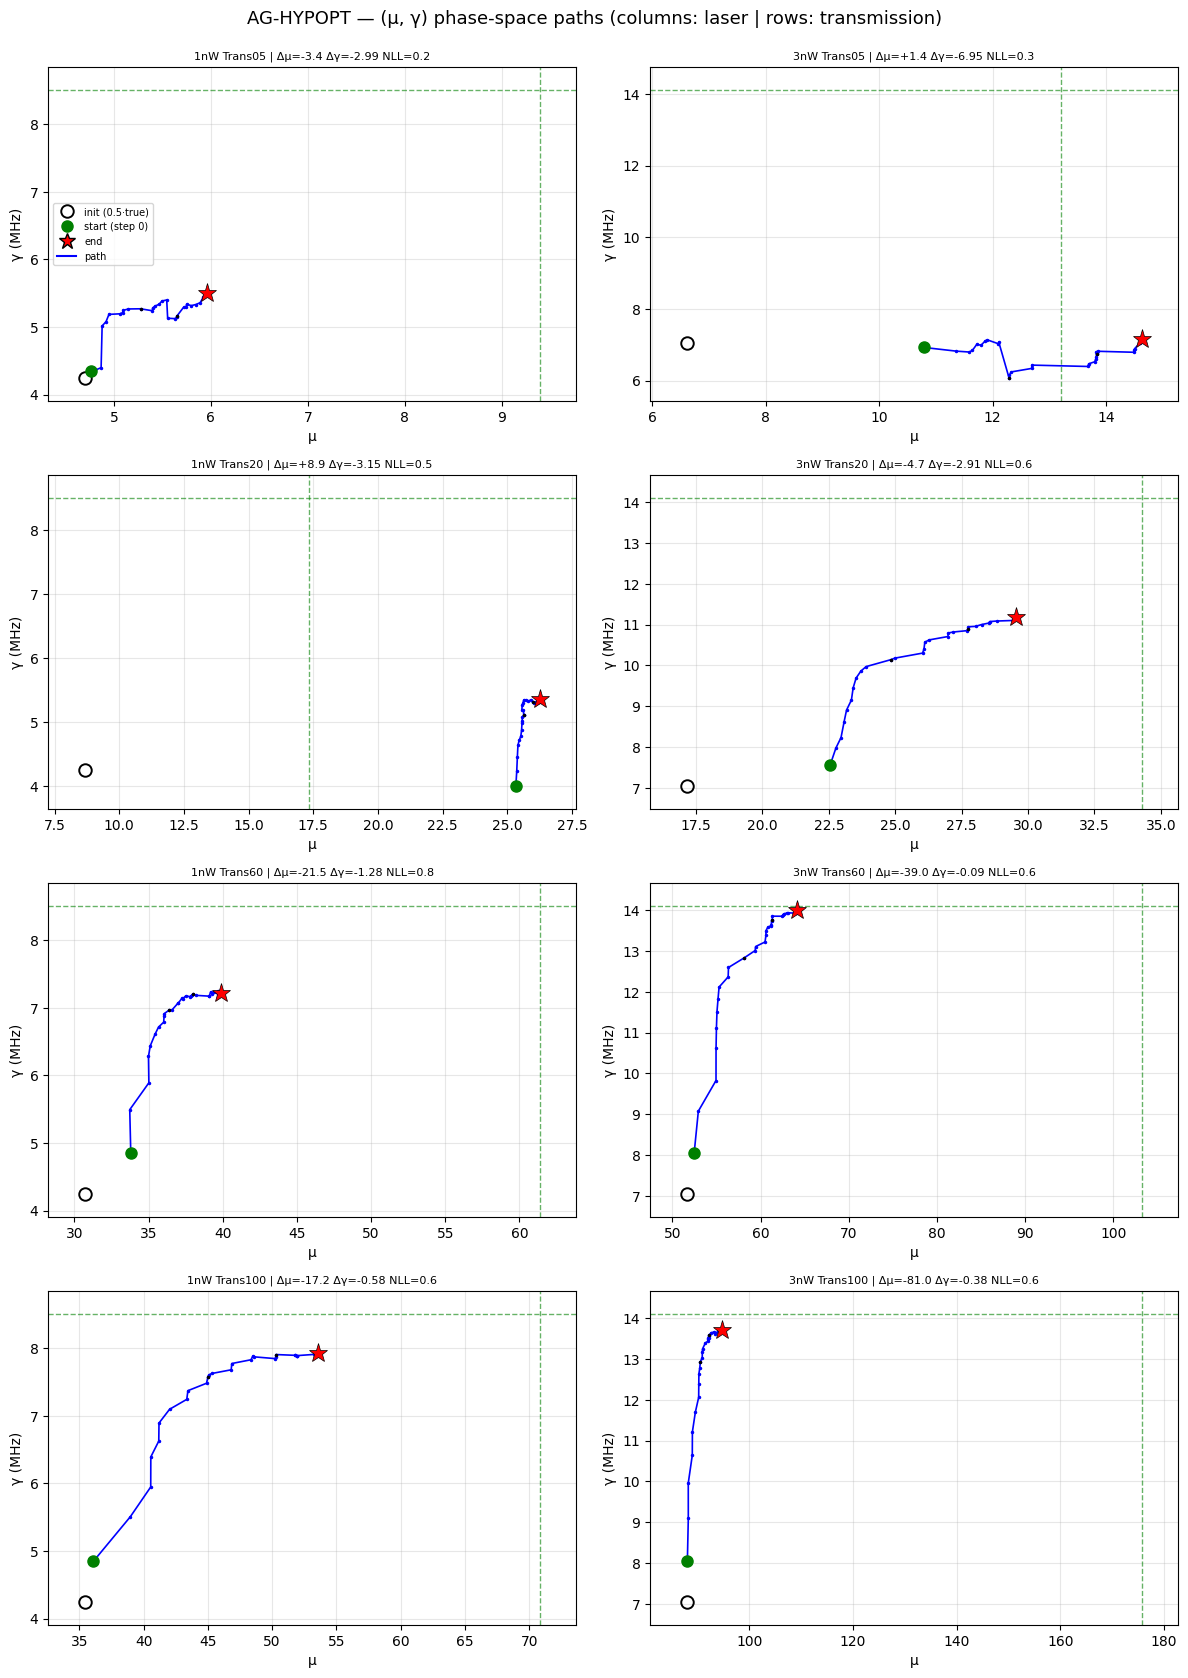

trial finished in 7.8 min
objective = 0.0850 ± 0.0224
exp              μ_true   μ_fit     Δμ% |   γ_true   γ_fit     Δγ%
1nW Trans05        9.39    5.96   -36.5 |     8.50    5.51   -35.2
1nW Trans20       17.32   26.26   +51.6 |     8.50    5.35   -37.0
1nW Trans60       61.37   39.92   -35.0 |     8.50    7.22   -15.0
1nW Trans100       70.82   53.59   -24.3 |     8.50    7.92    -6.8
3nW Trans05       13.20   14.63   +10.8 |    14.10    7.15   -49.3
3nW Trans20       34.28   29.55   -13.8 |    14.10   11.19   -20.6
3nW Trans60      103.20   64.16   -37.8 |    14.10   14.01    -0.6
3nW Trans100      175.71   94.71   -46.1 |    14.10   13.72    -2.7

weighted objective (T-graded, cap=1.0) = 0.0850 | diverged cells: 0
μ: RMSE 33.464 (rel 34.8%, bias -19.565) | γ: RMSE 3.116 (rel 26.8%, bias -2.289)


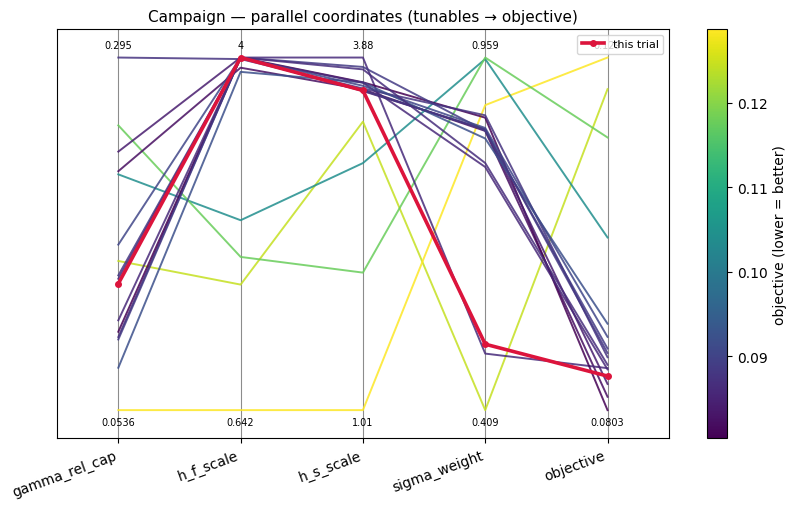

In [ ]:
# 5. ▶ RUN - Execute the chosen trial  (do not interrupt unless obviously broken)
assert INDEX is not None, 'INDEX not set: edit the SET cell (cell 4) before running this one'
assert 1 <= INDEX <= len(proposed_trials), f'bad INDEX: {INDEX}'
CHOSEN = proposed_trials[INDEX - 1]['params']
print('chosen:', CHOSEN)

from ag_hypopt import objective

import traceback, time
t0 = time.time()
try:
    loss, uncertainty, report = objective(CHOSEN)
    print(f'trial finished in {(time.time()-t0)/60:.1f} min')
    print(f'objective = {loss:.4f} ± {uncertainty:.4f}')
    print(report)
except Exception:
    traceback.print_exc()
    loss, uncertainty = None, None

# parallel coordinates: every recorded trial + this one (color = objective)
from ag_hypopt import plot_parallel
if loss is not None:
    plot_parallel(TRIALS_PATH, current={'config': CHOSEN, 'objective': loss})


## 6. ✍️ WRITE - Analyze the results

Record what actually happened in this trial: the measured objective, how the chosen
configuration behaved, and how that compares with the previous trials. No hypothesis to
confirm or refute, and no expectation to check: just the facts.

Trial 16 (sw 0.512, h_f 4.0, h_s 3.608, cap 0.140) ran to completion in 7.8 min with 0 diverged cells and gamma finite on all 8 cells; objective 0.0850 +/- 0.0224 - fourth best, worse than trial_07 (0.0803) but better than trial_11 and trial_06.

mu rel-RMSE 34.8% is near the best (trial_06 34.0%): the moderate-low sigma weight gives the strongest mu, with the usual shape - high-T undershoot (3nW Trans100 -46.1%, 3nW Trans60 -37.8%, 1nW Trans60 -35.0%, 1nW Trans100 -24.3%), low-T overshoot (1nW Trans20 +51.6%, 3nW Trans05 +10.8%); bias -19.57.

gamma rel-RMSE 26.8% (worse than trial_07's 22.3%): low T under-estimated (3nW Trans05 -49.3%, 1nW Trans20 -37.0%, 1nW Trans05 -35.2%), high T near truth (-0.6%, -2.7%).

The candidate re-ran trial_06's moderate-low sigma weight (0.512 vs 0.497) with the now-optimal kernels (h_f 4.0, h_s 3.608) and a good cap: mu matched trial_06's strong value while gamma stayed short, so the objective again exceeded trial_07. This confirms the mu-gamma tradeoff through sigma_weight, with trial_07 holding the best balance; the campaign still shows no improvement over trial_07.

**Summary:** Trial 16 (sw=0.512, h_f=4.0, h_s=3.608, cap=0.140) finished in 7.8 min with 0 diverged cells and gamma finite, objective 0.0850 +/- 0.0224 - fourth best, above trial_07 (mu rel-RMSE 34.8%, gamma rel-RMSE 26.8%).
**Key insight:** The moderate-low sigma weight (0.512) again gave strong mu (34.8%) but the objective (0.0850) stays above trial_07, so no single point beats trial_07's mu-gamma balance.

Structural-change proposals (score, likelihood, model, protocol) belong here as notes for
Anuar: describe them, never act on them, never stop the campaign because of them.
Notes for Anuar: none (no structural-change proposals).


In [ ]:
# 7. ✍️ SET - Summary and key insight for the record (edit the strings below, then run)
SUMMARY = 'Trial 16 (sw=0.512, h_f=4.0, h_s=3.608, cap=0.140): objective 0.0850 +/- 0.0224 - fourth best, worse than trial_07; 0 diverged cells, gamma finite (mu rel-RMSE 34.8%, gamma rel-RMSE 26.8%).'
KEY_INSIGHT = 'The moderate-low sigma weight (0.512) again gave strong mu (34.8%) but the objective (0.0850) stays above trial_07, so no single point beats trial_07 mu-gamma balance.'


In [ ]:
# 8. ▶ RUN - Record the trial in trials.json
import json

assert SUMMARY is not None, 'SUMMARY not set: fill the SET cell (cell 7) first'
assert KEY_INSIGHT is not None, 'KEY_INSIGHT not set: fill the SET cell (cell 7) first'

entry = {
    'trial_id': TRIAL_ID,
    'config': CHOSEN,
    'objective': loss,
    'uncertainty': uncertainty,
    'summary': SUMMARY,
    'key_insight': KEY_INSIGHT,
    'notebook': f'{TRIAL_ID}.ipynb',
}
data = json.load(open(TRIALS_PATH))
assert not any(t.get('trial_id') == TRIAL_ID for t in data['trials']),     f'{TRIAL_ID} is already registered in trials.json'
data['trials'].append(entry)
json.dump(data, open(TRIALS_PATH, 'w'), indent=2)
best = min((t for t in data['trials'] if t.get('objective') is not None),
           key=lambda t: t['objective'], default=None)
print('saved', TRIAL_ID, '| current best:', best['trial_id'] if best else None)


saved trial_16 | current best: trial_07


In [ ]:
# 9. ▶ RUN - Generate the next trial (or end the campaign)
import os, re, json as _json

num = int(re.search(r'(\d+)$', TRIAL_ID).group(1))
nxt = num + 1
if MAX_TRIALS is not None and nxt > MAX_TRIALS:
    print(f'Campaign complete: cap MAX_TRIALS={MAX_TRIALS} reached after {TRIAL_ID}. Stop here.')
else:
    template_path = os.path.join(EXPERIMENT_DIR, 'template.ipynb')
    target = os.path.join(EXPERIMENT_DIR, f'trial_{nxt:02d}.ipynb')
    assert not os.path.exists(target), f'{target} already exists: refusing to overwrite'

    nb = _json.load(open(template_path))

    def _stamp(old, new):
        for c in nb['cells']:
            if old in ''.join(c.get('source', [])):
                c['source'] = [s.replace(old, new) for s in c['source']]
                return True
        raise RuntimeError(f'stamp target {old!r} not found in the template')

    _stamp('{N}', f'{nxt:02d}')
    _stamp('trial_XXX', f'trial_{nxt:02d}')
    _json.dump(nb, open(target, 'w'), indent=1)
    print(f'Created {os.path.basename(target)}. Open it and follow its cells from the top.')


Created trial_17.ipynb. Open it and follow its cells from the top.
